In [3]:
#set colors
import matplotlib.pyplot as plt

# ── Theme colors ───────────────────────────────────────────
GES_DARK  = '#01010b'   # black
GES_BLUE  = '#6950ec'   # purple
GES_GOLD  = '#e00e32'   # berry red
GES_TEAL  = '#a3055c'   # maroon

PALETTE = [
    '#6950ec',  # purple
    '#a3055c',  # maroon
    '#e00e32',  # berry red
    '#9e9e9e',  # gray
    '#8a7cff',  # soft purple
    '#c75a93',  # dusty pink
    '#d9d9d9',  # light gray
    '#b23a6f'   # muted berry
]

# ── Global chart settings ──────────────────────────────────
FIGSIZE = (10, 6)
TITLE_SIZE = 14
LABEL_SIZE = 11
TICK_SIZE = 10
BAR_LABEL_SIZE = 9
ROTATION = 20
GRID_ALPHA = 0.35
BAR_ALPHA = 0.9
EDGE_COLOR = '#d9d9d9'

plt.rcParams.update({
    'figure.facecolor':  GES_DARK,
    'axes.facecolor':    '#141420',
    'savefig.facecolor': GES_DARK,
    'axes.edgecolor':    '#444',
    'axes.labelcolor':   'white',
    'xtick.color':       '#ccc',
    'ytick.color':       '#ccc',
    'text.color':        'white',
    'grid.color':        '#333',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

In [7]:
import pandas as pd

df = pd.read_csv("Data/merged_customer_data.csv")
df.head()

,Transaction ID,Customer ID,Transaction Date,Business Line,Product/Service,Revenue,Data Source,Region,Source Type,Primary Business Line,...,Source ID,Business Line_ds,Data Source Name,Source Type_ds,Customer ID Available,Email Available,Demographics Available,Data Quality,Integration Status,Notes
0,TXN000001,CUST00150,2024-01-01,Consumer Products,Merchandise - Collectibles,54.06,3rd Party - Walmart,East Coast,3rd Party,Consumer Products,...,8,Consumer Products,3rd Party - Walmart,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
1,TXN000002,CUST00642,2024-01-01,Consumer Products,Merchandise - Apparel,40.87,3rd Party - Target,West Coast,3rd Party,Consumer Products,...,7,Consumer Products,3rd Party - Target,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
2,TXN000003,CUST00035,2024-01-01,Streaming,Monthly Subscription,10.72,1st Party - Streaming Platform,Southwest,1st Party,Streaming,...,1,Streaming,1st Party - Streaming Platform,1st Party,Yes,Yes,Yes (80% complete),High,Fully Integrated,Complete customer profiles with viewing history
3,TXN000004,CUST00163,2024-01-02,Theatrical,Mystery Manor,17.24,3rd Party - AMC Theatres,Southwest,3rd Party,Theatrical,...,4,Theatrical,3rd Party - AMC Theatres,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...
4,TXN000005,CUST00185,2024-01-02,Theatrical,Space Odyssey 2,27.81,3rd Party - Cinemark,East Coast,3rd Party,Theatrical,...,6,Theatrical,3rd Party - Cinemark,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...


### Date setup

In [9]:
# Convert date columns
date_cols = ["Transaction Date", "First Interaction", "Last Interaction"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Clean numeric fields
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

# Drop bad rows for time analysis
df = df.dropna(subset=["Transaction Date"]).copy()

# Sort
df = df.sort_values("Transaction Date")

# Add time fields
df["Year"] = df["Transaction Date"].dt.year
df["Month"] = df["Transaction Date"].dt.month
df["Month Start"] = df["Transaction Date"].dt.to_period("M").dt.to_timestamp()

print("Shape:", df.shape)

Shape: (2500, 34)


,Transaction ID,Customer ID,Transaction Date,Business Line,Product/Service,Revenue,Data Source,Region,Source Type,Primary Business Line,...,Source Type_ds,Customer ID Available,Email Available,Demographics Available,Data Quality,Integration Status,Notes,Year,Month,Month Start
0,TXN000001,CUST00150,2024-01-01,Consumer Products,Merchandise - Collectibles,54.06,3rd Party - Walmart,East Coast,3rd Party,Consumer Products,...,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...,2024,1,2024-01-01
1,TXN000002,CUST00642,2024-01-01,Consumer Products,Merchandise - Apparel,40.87,3rd Party - Target,West Coast,3rd Party,Consumer Products,...,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...,2024,1,2024-01-01
2,TXN000003,CUST00035,2024-01-01,Streaming,Monthly Subscription,10.72,1st Party - Streaming Platform,Southwest,1st Party,Streaming,...,1st Party,Yes,Yes,Yes (80% complete),High,Fully Integrated,Complete customer profiles with viewing history,2024,1,2024-01-01
3,TXN000004,CUST00163,2024-01-02,Theatrical,Mystery Manor,17.24,3rd Party - AMC Theatres,Southwest,3rd Party,Theatrical,...,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...,2024,1,2024-01-01
4,TXN000005,CUST00185,2024-01-02,Theatrical,Space Odyssey 2,27.81,3rd Party - Cinemark,East Coast,3rd Party,Theatrical,...,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...,2024,1,2024-01-01


## Looking at monthly transactions

All data is from 2024

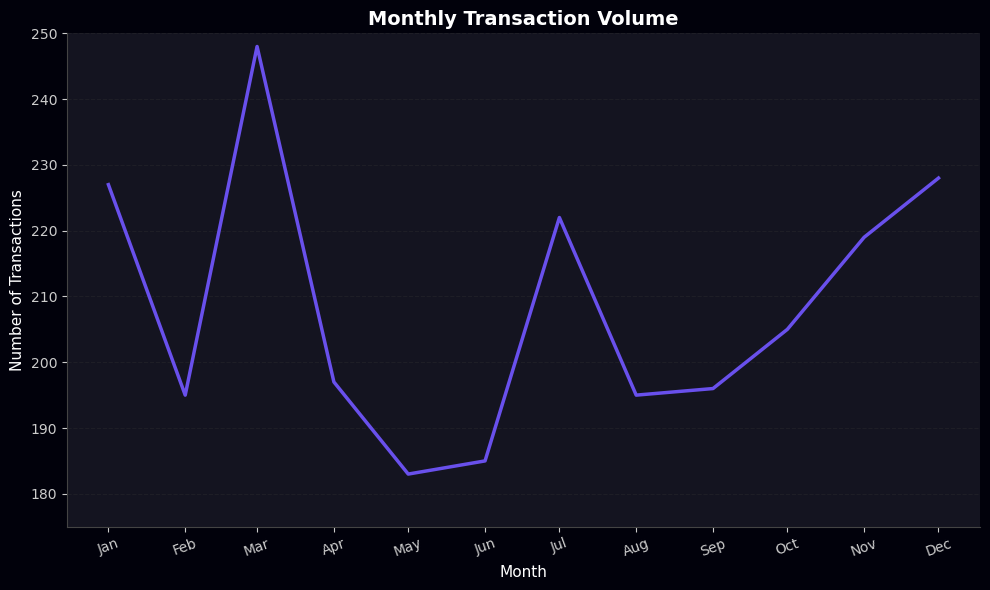

In [27]:
import matplotlib.dates as mdates

monthly_txns = (
    df.groupby("Month Start")
      .size()
      .reset_index(name="Transactions")
)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(
    monthly_txns["Month Start"],
    monthly_txns["Transactions"],
    color=PALETTE[0],
    linewidth=2.5
)

ax.set_title("Monthly Transaction Volume", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_xlabel("Month", fontsize=LABEL_SIZE)
ax.set_ylabel("Number of Transactions", fontsize=LABEL_SIZE)
ax.grid(True, axis="y", alpha=GRID_ALPHA)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(175, 250)
plt.xticks(rotation=ROTATION)
plt.tight_layout()
plt.show()

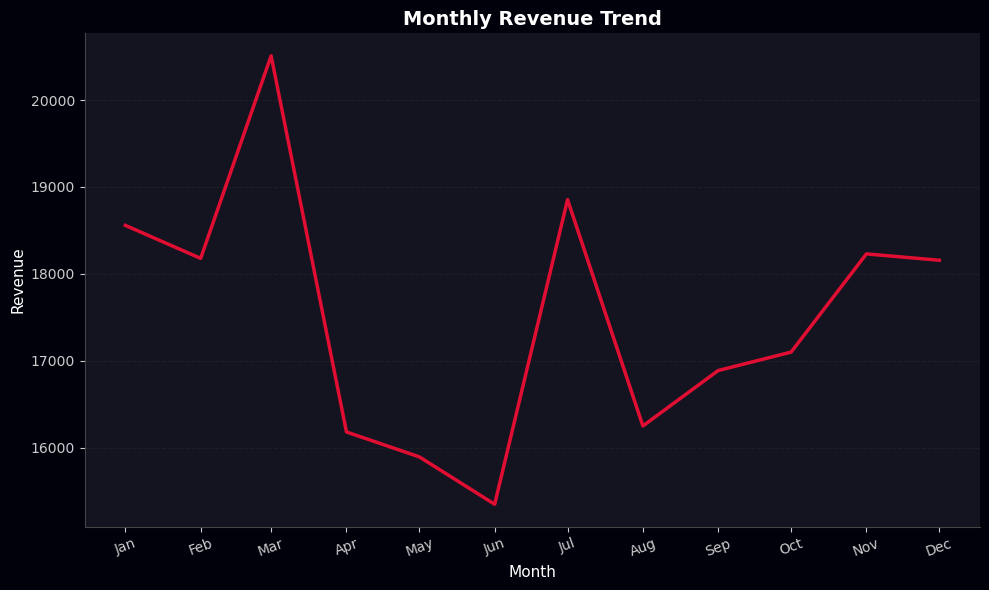

In [29]:
monthly_revenue = (
    df.groupby("Month Start")["Revenue"]
      .sum()
      .reset_index()
)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(
    monthly_revenue["Month Start"],
    monthly_revenue["Revenue"],
    color=PALETTE[2],
    linewidth=2.5
)

ax.set_title("Monthly Revenue Trend", fontsize=TITLE_SIZE, fontweight="bold")
ax.set_xlabel("Month", fontsize=LABEL_SIZE)
ax.set_ylabel("Revenue", fontsize=LABEL_SIZE)
ax.grid(True, axis="y", alpha=GRID_ALPHA)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xticks(rotation=ROTATION)
plt.tight_layout()
plt.show()

Very similar distribution

1. missing identifieres over time (month/week)
2. 